In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import torch, os, numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

[transformers] Disabling PyTorch because PyTorch >= 2.4 is required but found 2.2.2
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [3]:
print('\n=== Face folder check ===')
total_videos = 0
for split in ['train', 'val', 'test']:
    for cls in ['real', 'fake']:
        path = f'/content/content/faces/{split}/{cls}'
        if os.path.exists(path):
            folders = [f for f in os.listdir(path)
                       if os.path.isdir(f'{path}/{f}')]
            total_videos += len(folders)
            print(f'{split:5s}/{cls:4s} → {len(folders):4d} folders')
        else:
            print(f'❌ Missing: {path}')


=== Face folder check ===
train/real →  350 folders
train/fake →  350 folders
val  /real →   75 folders
val  /fake →   75 folders
test /real →   75 folders
test /fake →   75 folders


In [4]:
class DeepfakeDataset(Dataset):
    def __init__(self, root, split='train', augment=False):
        """
        root    : FACE_OUT path
        split   : train / val / test
        augment : True for training only
        NUM_FRAMES is 10 (updated from 30)
        """
        self.num_frames = 5  # 10 from config

        if augment:
            self.transform = transforms.Compose([
                transforms.Resize((224,224)),
                transforms.RandomHorizontalFlip(p=0.5),
                transforms.ColorJitter(
                    brightness=0.2,
                    contrast=0.2,
                    saturation=0.2),
                transforms.GaussianBlur(
                    kernel_size=3, sigma=(0.1, 1.0)),
                transforms.ToTensor(),
                transforms.Normalize([0.5]*3, [0.5]*3)
            ])
        else:
            self.transform = transforms.Compose([
                transforms.Resize((224,224)),
                transforms.ToTensor(),
                transforms.Normalize([0.5]*3, [0.5]*3)
            ])

        self.samples = []
        for label_idx, cls in enumerate(['real', 'fake']):
            cls_dir = f'{root}/{split}/{cls}'
            if not os.path.exists(cls_dir):
                continue
            for folder in sorted(os.listdir(cls_dir)):
                fpath = f'{cls_dir}/{folder}'
                if os.path.isdir(fpath) and \
                   len(os.listdir(fpath)) >= 3:
                    self.samples.append((fpath, label_idx))

        print(f'[{split:5s}] {len(self.samples):4d} sequences '
              f'| augment={augment}')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        folder, label = self.samples[idx]
        files  = sorted(os.listdir(folder))[:self.num_frames]
        frames = []

        for fname in files:
            img = Image.open(f'{folder}/{fname}').convert('RGB')
            frames.append(self.transform(img))

        # Pad if video shorter than num_frames
        while len(frames) < self.num_frames:
            frames.append(frames[-1])

        # [10, 3, 224, 224]
        return torch.stack(frames), \
               torch.tensor(label, dtype=torch.float32)


In [6]:
train_ds = DeepfakeDataset(
    root='/content/content/faces',
    split='train',
    augment=True
)

[train]  700 sequences | augment=True


In [7]:
frames1, _ = train_ds[0]
frames2, _ = train_ds[0]

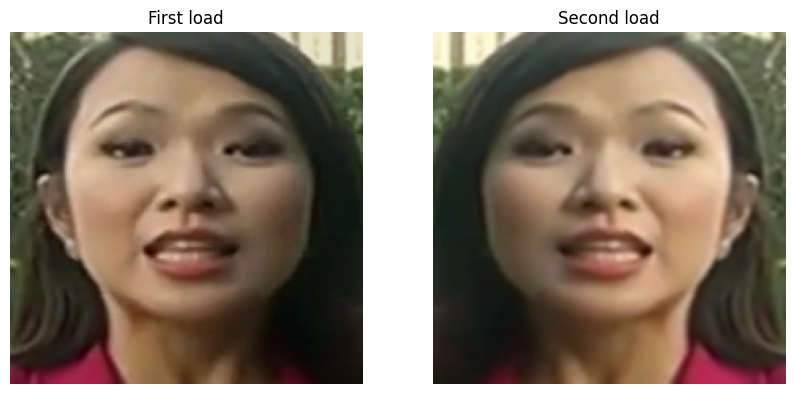

In [8]:
import matplotlib.pyplot as plt

def denorm(x):
    return (x * 0.5 + 0.5).clamp(0,1)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(
    denorm(frames1[0]).permute(1,2,0)
)
plt.title("First load")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(
    denorm(frames2[0]).permute(1,2,0)
)
plt.title("Second load")
plt.axis("off")

plt.show()

In [9]:
train_ds = DeepfakeDataset('/content/content/faces', 'train', augment=True)
val_ds   = DeepfakeDataset('/content/content/faces', 'val',   augment=False)
test_ds  = DeepfakeDataset('/content/content/faces', 'test',  augment=False)

[train]  700 sequences | augment=True
[val  ]  150 sequences | augment=False
[test ]  150 sequences | augment=False


In [10]:
BATCH_SIZE=8

In [11]:
train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE,
    shuffle=True,  num_workers=2, pin_memory=True)

val_loader = DataLoader(
    val_ds,   batch_size=BATCH_SIZE,
    shuffle=False, num_workers=2, pin_memory=True)

test_loader = DataLoader(
    test_ds,  batch_size=BATCH_SIZE,
    shuffle=False, num_workers=2, pin_memory=True)

print(f'\nTrain batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')
print(f'Test batches  : {len(test_loader)}')


Train batches : 88
Val batches   : 19
Test batches  : 19


In [12]:
import os

os.makedirs(
    "/content/drive/MyDrive/DeepfakeProject/outputs",
    exist_ok=True
)

In [53]:
torch.save({
    'train' : train_ds,
    'val'   : val_ds,
    'test'  : test_ds,
}, f'/content/drive/MyDrive/DeepfakeProject/outputs/datasets.pt')



In [13]:
frames, labels = next(iter(train_loader))
print(f'Batch frames : {frames.shape}')  # [8, 30, 3, 224, 224]
print(f'Batch labels : {labels}')
print(f'Pixel range  : {frames.min():.2f} → {frames.max():.2f}')

Batch frames : torch.Size([8, 5, 3, 224, 224])
Batch labels : tensor([0., 0., 1., 1., 1., 1., 1., 1.])
Pixel range  : -1.00 → 1.00


In [60]:
import os

os.makedirs(
    "/content/drive/MyDrive/DeepfakeProject/outputs/results",
    exist_ok=True
)

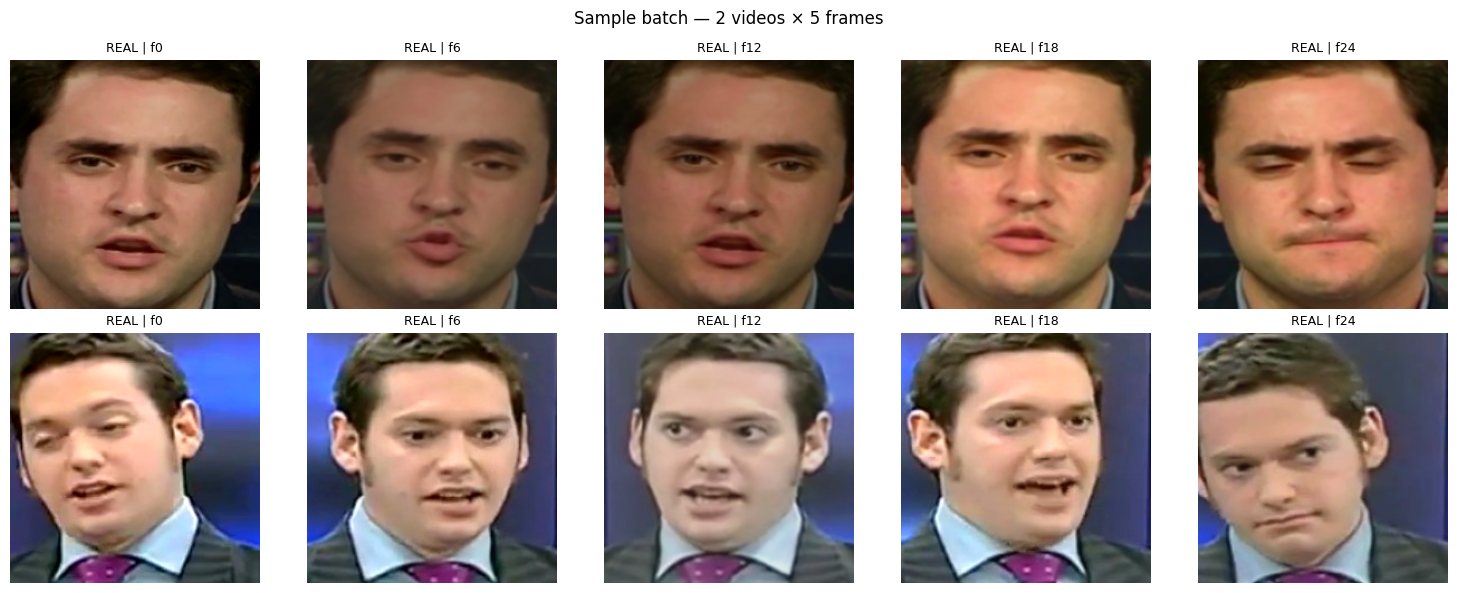

Dataset preparation complete — ready for model!


In [14]:
def denorm(t):
    return (t * 0.5 + 0.5).clamp(0, 1)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for row in range(2):
    for col in range(5):
        ax = axes[row][col]
        img = denorm(frames[row][col]).permute(1,2,0).numpy()
        ax.imshow(img)
        lbl = 'REAL' if labels[row].item()==0 else 'FAKE'
        ax.set_title(f'{lbl} | f{col*6}', fontsize=9)
        ax.axis('off')
plt.suptitle('Sample batch — 2 videos × 5 frames', fontsize=12)
plt.tight_layout()
plt.savefig(f'/content/drive/MyDrive/DeepfakeProject/outputs/results/sample_batch.png')
plt.show()


In [73]:
pip install facenet_pytorch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 33.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 65.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.5/755.5 MB 697.8 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 73.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 69.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.

In [15]:
from facenet_pytorch import MTCNN
from PIL import Image
import random, os

mtcnn = MTCNN(keep_all=False)

bad = 0
total = 0

for root, dirs, files in os.walk('/content/content/faces'):
    for f in random.sample(files, min(len(files), 5)):
        img = Image.open(os.path.join(root, f))

        if mtcnn.detect(img)[0] is None:
            bad += 1

        total += 1

print("Bad:", bad)
print("Total:", total)
print("Bad %:", 100 * bad / total)

Bad: 509
Total: 5000
Bad %: 10.18
